# Fine-tuned ResNet50V2
Train and evaluate the Fine-tuned ResNet50V2 variant on the fixed six-identity split. The best checkpoint is selected by validation loss.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "src").is_dir():
    raise RuntimeError("Start Jupyter in ie7615-project1 or ie7615-project1/notebooks")
sys.path.insert(0, str(ROOT))
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display, Image
from utils import set_seed
from src.config import DATA_DIR, SEED, EPOCHS, BATCH_SIZE
from src.experiment import get_active_run
from src.models import load_datasets, build_custom_cnn, build_resnet, train_and_evaluate

2026-09-27 02:44:00.571006: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790491440.746867 1053149 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790491440.790962 1053149 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790491441.277381 1053149 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790491441.277410 1053149 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790491441.277412 1053149 computation_placer.cc:177] computation placer alr

## Data and Reproducibility

In [2]:
RUN_DIR = get_active_run()
# Reset random sequences before dataset and model construction.
tf.keras.backend.clear_session()
set_seed(SEED)
train_ds, val_ds, test_ds, class_names, manifest = load_datasets(DATA_DIR, BATCH_SIZE, seed=SEED)
display(manifest.groupby(["identity", "split"]).size().unstack()[["train", "val", "test"]])
print("Run:", RUN_DIR)
print("Classes:", class_names)

Found 102 files belonging to 6 classes.


I0000 00:00:1790491448.318312 1053149 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31141 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:3b:00.0, compute capability: 7.0


Found 24 files belonging to 6 classes.
Found 24 files belonging to 6 classes.


split,train,val,test
identity,,,
2336,17,4,4
2619,17,4,4
2970,17,4,4
3,17,4,4
4422,17,4,4
797,17,4,4


Run: /home/zhang.jiaso/ondemand/data/sys/dashboard/batch_connect/sys/jupyterlab-ml-courses/ie7615-project1/runs/20260926T151014Z_08ffd273
Classes: ['2336', '2619', '2970', '3', '4422', '797']


## Architecture

In [3]:
model = build_resnet(len(class_names), mode="finetune")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │        12,294 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,577,094 (89.94 MB)

 Trainable params: 23,531,654 (89.77 MB)

 Non-trainable params: 45,440 (177.50 KB)

## Training and Held-out Evaluation

In [4]:
result = train_and_evaluate(model, "ResNet_Finetuned", train_ds, val_ds, test_ds,
                            class_names, manifest, RUN_DIR, epochs=EPOCHS, seed=SEED)
display(pd.DataFrame([result]))

Epoch 1/20


I0000 00:00:1790491474.881669 1053221 cuda_dnn.cc:529] Loaded cuDNN version 90300


13/13 ━━━━━━━━━━━━━━━━━━━━ 29s 310ms/step - accuracy: 0.1951 - loss: 1.9499 - val_accuracy: 0.4167 - val_loss: 1.3870
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.6902 - loss: 0.9333 - val_accuracy: 0.5833 - val_loss: 0.9392
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step - accuracy: 0.8263 - loss: 0.6673 - val_accuracy: 0.7083 - val_loss: 0.6901
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.9377 - loss: 0.3640 - val_accuracy: 0.6667 - val_loss: 0.5202
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 0.9445 - loss: 0.2790 - val_accuracy: 0.9167 - val_loss: 0.2631
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.9937 - loss: 0.0815 - val_accuracy: 0.8333 - val_loss: 0.3529
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 188ms/step - accuracy: 0.9769 - loss: 0.1159 - val_accuracy: 1.0000 - val_loss: 0.1092
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 174ms/step - accuracy: 0.9721 - loss: 0.1075 - val_accuracy: 1.0000 - val_

2026-09-27 02:45:08.140177: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,model,inference_ms_median,inference_repeats,inference_batch_size,total_parameters,trainable_parameters,training_seconds,epochs_completed,best_epoch,best_val_loss,test_accuracy,test_loss,correct,test_count,seed,learning_rate,batch_size,checkpoint_sha256
0,ResNet_Finetuned,144.180854,30,1,23577094,23531654,53.335375,16,11,0.029987,0.958333,0.17833,23,24,42,0.0001,8,4b9e803dcc20947c7ab3cb818db3ecb5bf5bcbc5690475...


## Learning Curves and Confusion Matrix

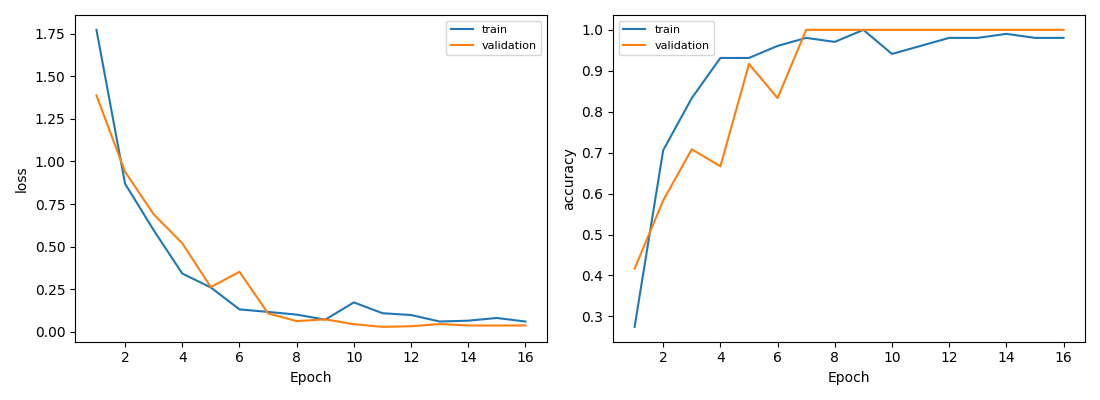

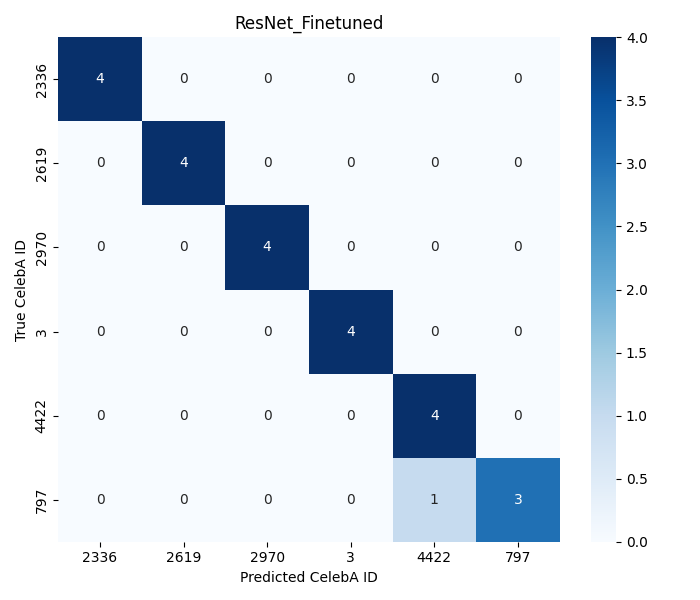

In [5]:
display(Image(filename=str(RUN_DIR / "ResNet_Finetuned" / "learning_curves.png")))
display(Image(filename=str(RUN_DIR / "ResNet_Finetuned" / "confusion_matrix.png")))

## Checkpoint Reload Verification
Reconstruct the architecture and compare all test probabilities against the saved predictions.

In [6]:
restored = build_resnet(len(class_names), mode="finetune", weights=None)
restored.load_weights(str(RUN_DIR / "ResNet_Finetuned" / "best.weights.h5"))
probabilities = restored.predict(test_ds, verbose=0)
saved = pd.read_csv(RUN_DIR / "ResNet_Finetuned" / "predictions.csv")
columns = [f"probability_{i}" for i in range(len(class_names))]
np.testing.assert_allclose(probabilities, saved[columns].to_numpy(), rtol=1e-5, atol=1e-6)
verification = {"passed": True, "rtol": 1e-5, "atol": 1e-6, "test_images": len(saved)}
(RUN_DIR / "ResNet_Finetuned" / "reload_verification.json").write_text(
    json.dumps(verification, indent=2), encoding="utf-8")
print("Checkpoint probabilities verified for all test images.")

/opt/miniconda/envs/eai/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 350 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Checkpoint probabilities verified for all test images.
